# Manipulator beside a person

Section V-B of the paper on Warp and MuJoCo Warp, without JAX: Table II, and 20 of the 100 updates of Table III at four of its 16 pick and handover locations. One CUDA GPU with 14 GB free, float32 through the simulation and float64 for the exact robustness; about 5.5 minutes on an NVIDIA RTX PRO 6000 Blackwell Max-Q.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
import numpy as np
import warp as wp
from IPython.display import Markdown

from sparsemax_dstl.tasks import workspace_program as spec
from sparsemax_dstl.tasks import workspace_scene as scene
from sparsemax_dstl.tasks import workspace_warp as manipulator
from sparsemax_dstl.warp import Evaluator, matched_param, solver, solver_conjuncts

wp.config.log_level = wp.LOG_WARNING
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
Path("out").mkdir(exist_ok=True)
dev = "cuda:0"


def table(header, rows):
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    lines += ["| " + " | ".join(str(x) for x in row) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

The scene at $H = 10$ s with the pick window $[w, w + 1]$ at $w = 7.22$ s, and Equation (19) compiled for its value at $t = 0$, whole and per conjunct.

In [2]:
I = scene.load("data/manipulator_H10.npz")
sc = scene.scenario(10, 7.22)
phi = spec.core_program(sc, I["n_h"])
conjuncts = spec.conj_programs(sc, I["n_h"])
print(sc.samples, "samples,", phi.n_predicates, "predicates,", spec.N_R, "spheres on the manipulator,", I["n_h"], "on the person")
print("pick target", I["pick"][0].round(4), "handover target", I["handover"][0].round(4), "zone centre", sc.zone, "radius", sc.zone_radius)
print("rows of the evaluation graph:", dict(zip(spec.CONJUNCTS, [sum(s.length for s in p.steps if s.kind != "atom") for p in conjuncts])))

501 samples, 1708 predicates, 31 spheres on the manipulator, 27 on the person
pick target [0.3308 0.     0.1158] handover target [0.4175 0.     0.0565] zone centre (0.5, 0.0, 0.0) radius 0.2
rows of the evaluation graph: {'separation': 502, 'slowdown': 31564, 'order': 52, 'handover': 11}


The four initial trajectories of `data/manipulator_H10.npz` on the float64 MuJoCo replay: exact robustness of the specification and of each conjunct.

In [3]:
Z, M = manipulator.replay_predicates(I, sc, dev)


def exact(prog):
    x = wp.array(M, dtype=wp.float64, device=dev)
    return Evaluator(prog, "exact", None, len(M), wp.float64, dev, P=M.shape[-1]).value(x).numpy()[:, 0]


print("specification", exact(phi).round(5))
print("separation", exact(conjuncts[0]).round(3))
print("slow-down", exact(conjuncts[1]).round(3))
print("until", exact(conjuncts[2]).round(5))
print("handover", exact(conjuncts[3]).round(3))

specification [-0.04999 -0.04999 -0.04999 -0.04999]
separation [0.687 0.687 0.687 0.687]
slow-down [0.998 0.998 0.998 0.998]
until [-0.04999 -0.04999 -0.04999 -0.04999]
handover [0.994 0.994 0.994 0.994]


Table II: the until conjunct $\mathit{clear}\ \mathcal{U}_{[w, w+1]}\ \mathit{pick}$ with $w = H - 2.78$ s under each measure at $\varepsilon = 0.2$: its value, its weight on the samples inside the zone, and the norm of the torque gradient through those samples; medians over the four trajectories.

In [4]:
measures = ("lse_plain", "lse", "gm_pm01", "gm_pm10", "sparsemax")
names = {"lse_plain": "plain LSE", "lse": "sound LSE", "gm_pm01": "GMR (0, 1)", "gm_pm10": "GMR (-10, 10)", "sparsemax": "sparsemax"}


def until_conjunct(H):
    I = scene.load("data/manipulator_H" + str(H) + ".npz")
    sc, prog, kw = scene.until_program(H, I["wait"][0], I["n_h"])
    Z, _ = manipulator.replay_predicates(I, sc, dev)
    inside = (Z[:, :, 2] < 0) & (np.arange(sc.samples) <= kw[-1])  # predicate 2 is clear
    x = wp.array(Z, dtype=wp.float64, device=dev)
    value, weight = [], []
    for m in measures:
        rho, G = Evaluator(prog, m, matched_param(prog, m, 0.2), len(Z), wp.float64, dev, P=Z.shape[-1]).gradient(x)
        value.append(rho.numpy()[:, 0])
        weight.append(np.where(inside, G.numpy()[:, :, 2], 0).sum(1))
    g = manipulator.until_torque_gradient(I, sc, prog, kw, inside, [(m, 0.2) for m in measures], dev)
    return np.median(value, 1), np.median(weight, 1), np.median(g["grad_norm_viol"], 1)


v10, w10, g10 = until_conjunct(10)
v20, w20, g20 = until_conjunct(20)
v40, w40, g40 = until_conjunct(40)
v80, w80, g80 = until_conjunct(80)

In [5]:
W = np.stack([w10, w20, w40, w80], 1).round(4)
G = np.stack([g10, g20, g40, g80], 1).round(3)
rows = [["exact", np.median(exact(conjuncts[2])).round(4)] + [""] * 8]
rows += [[names[m], v10[i].round(4)] + W[i].tolist() + G[i].tolist() for i, m in enumerate(measures)]
table(["measure", "value, 10 s", "weight, 10 s", "20 s", "40 s", "80 s", "torque gradient, 10 s", "20 s", "40 s", "80 s"], rows)

| measure | value, 10 s | weight, 10 s | 20 s | 40 s | 80 s | torque gradient, 10 s | 20 s | 40 s | 80 s |
|---|---|---|---|---|---|---|---|---|---|
| exact | -0.05 |  |  |  |  |  |  |  |  |
| plain LSE | 0.0227 | 0.2163 | 0.114 | 0.0644 | 0.0364 | 3.623 | 1.932 | 1.122 | 0.673 |
| sound LSE | -0.1773 | 0.2163 | 0.114 | 0.0644 | 0.0364 | 3.623 | 1.932 | 1.122 | 0.673 |
| GMR (0, 1) | -0.0006 | 0.0239 | 0.0104 | 0.0049 | 0.0024 | 0.396 | 0.172 | 0.081 | 0.039 |
| GMR (-10, 10) | -0.0292 | 0.5879 | 0.5411 | 0.5018 | 0.4668 | 10.099 | 9.295 | 8.619 | 8.018 |
| sparsemax | -0.2196 | 1.0 | 1.0 | 1.0 | 1.0 | 16.818 | 16.818 | 16.818 | 16.818 |

Equation (4) with $c = 0$, one constraint per conjunct: 20 updates under each measure from the two violating initial trajectories at each of four pick and handover locations of Table III, $H = 10$ s, $w = 7.22$ s.

In [6]:
R = scene.runs(scene.load("data/manipulator_H10_locations.npz"), measures, 0.2)
chain, referee = manipulator.conjunct_chain(R, device=dev)
state = solver_conjuncts.init_state(R["V0"], scene.ALPHA0, chain.K)
res = solver_conjuncts.solve(chain, referee, state, 20, scene.LAM, scene.DELTA)
rho = res["referee64"]

Exact robustness on the float64 replay against the update.

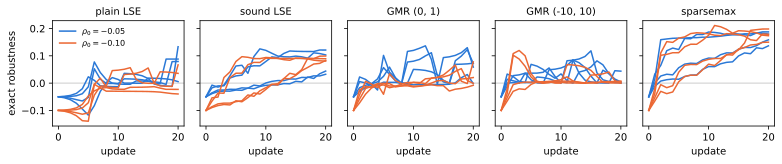

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(11, 2.4), sharey=True)
for ax, m in zip(axes, measures):
    ax.axhline(0, color="0.8", lw=1)
    a = ax.plot(rho[(R["measure"] == m) & (R["group"] == -0.05)].T, color="#2a78d6", lw=1.5)
    b = ax.plot(rho[(R["measure"] == m) & (R["group"] == -0.1)].T, color="#eb6834", lw=1.5)
    ax.set_title(names[m], fontsize=10)
    ax.set_xlabel("update")
axes[0].set_ylabel("exact robustness")
axes[0].legend([a[0], b[0]], [r"$\rho_0 = -0.05$", r"$\rho_0 = -0.10$"], frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig("out/manipulator_exact_robustness.svg")
fig.savefig("out/manipulator_exact_robustness.pdf")

First update with a nonnegative exact robustness, per location and initial exact robustness $\rho_0$; $-1$: none within the 20 updates.

In [8]:
first, _ = solver.certification(rho)
head = ["location " + str(l) + ", " + str(g) for l, g in zip(R["location"][:8], R["group"][:8])]
table(["measure"] + head, [[names[m]] + first[R["measure"] == m].tolist() for m in measures])

| measure | location 0, -0.05 | location 0, -0.1 | location 1, -0.05 | location 1, -0.1 | location 2, -0.05 | location 2, -0.1 | location 3, -0.05 | location 3, -0.1 |
|---|---|---|---|---|---|---|---|---|
| plain LSE | 6 | 9 | 6 | 7 | 5 | -1 | 8 | -1 |
| sound LSE | 4 | 4 | 10 | 13 | 15 | 13 | 4 | 3 |
| GMR (0, 1) | 1 | 2 | 4 | 10 | 4 | 9 | 1 | 6 |
| GMR (-10, 10) | 1 | 2 | 1 | 3 | 2 | 6 | 1 | 2 |
| sparsemax | 1 | 2 | 1 | 5 | 2 | 5 | 1 | 2 |

The eight runs of `deploy/orin/optimize.py`: sparsemax, $w = 2$ s, ten updates from the four initial trajectories of each $\rho_0$; exact robustness per run and update.

In [9]:
R8 = scene.runs(scene.load("data/manipulator_H10_w2.npz"), ("sparsemax",), 0.2)
chain, referee = manipulator.conjunct_chain(R8, device=dev)
state = solver_conjuncts.init_state(R8["V0"], scene.ALPHA0, chain.K)
res8 = solver_conjuncts.solve(chain, referee, state, 10, scene.LAM, scene.DELTA)
table(["run"] + [str(k) for k in range(11)], [[i] + r for i, r in enumerate(res8["referee64"].round(3).tolist())])

| run | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---|---|---|---|---|---|---|---|---|---|---|
| 0 | -0.05 | 0.022 | 0.085 | 0.144 | 0.181 | 0.2 | 0.19 | 0.178 | 0.147 | 0.155 | 0.172 |
| 1 | -0.05 | 0.022 | 0.049 | 0.14 | 0.146 | 0.167 | 0.187 | 0.184 | 0.183 | 0.209 | 0.203 |
| 2 | -0.05 | 0.022 | 0.14 | 0.176 | 0.177 | 0.185 | 0.199 | 0.186 | 0.185 | 0.197 | 0.2 |
| 3 | -0.05 | 0.022 | 0.115 | 0.165 | 0.173 | 0.182 | 0.19 | 0.192 | 0.191 | 0.199 | 0.196 |
| 4 | -0.1 | -0.031 | 0.125 | 0.073 | 0.177 | 0.211 | 0.211 | 0.214 | 0.18 | 0.18 | 0.178 |
| 5 | -0.1 | -0.031 | 0.122 | 0.144 | 0.163 | 0.209 | 0.211 | 0.212 | 0.191 | 0.181 | 0.176 |
| 6 | -0.1 | -0.031 | 0.125 | 0.159 | 0.197 | 0.194 | 0.189 | 0.208 | 0.209 | 0.207 | 0.189 |
| 7 | -0.1 | -0.03 | 0.126 | 0.127 | 0.196 | 0.19 | 0.203 | 0.201 | 0.197 | 0.19 | 0.186 |

Median seconds per update by component: the simulation (`rollout`), the predicates and the robustness with their gradient (`stl`), the reverse pass of the simulation (`plant_backward`), the line search (`trial_*`), the float64 replay (`referee_*`).

In [10]:
def seconds(res):
    return np.median(res["seconds"], 0).round(2).tolist() + [np.median(res["seconds"].sum(1)).round(2)]


table(["runs"] + list(res["seconds_keys"]) + ["total"], [[8] + seconds(res8), [40] + seconds(res)])
print(wp.get_device(dev).name)

| runs | rollout | stl | plant_backward | trial_rollout | trial_stl | referee_mujoco | referee_stl | solver | total |
|---|---|---|---|---|---|---|---|---|---|
| 8 | 1.14 | 0.02 | 4.08 | 1.26 | 0.01 | 0.02 | 0.03 | 0.0 | 6.56 |
| 40 | 1.21 | 0.05 | 4.62 | 1.52 | 0.03 | 0.05 | 0.15 | 0.0 | 7.63 |

NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition
